In [ ]:
import torch, torchvision
import torch.nn as nn
import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import re
from tqdm.notebook import tqdm

from shared import *

cudnn.benchmark = True
plt.ion();

In [ ]:
BASE = "cifar10-data"
BASE_PLOTS = os.path.join(BASE, "plots")
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR = 0.001
MOMENTUM = 0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 5

os.makedirs(BASE_PLOTS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


# 1. Baseline Setup

In [3]:
def process_fn(inp):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    return inp

def visualize(inputs, classes, dataloader):
    
    plt.figure(figsize=(10,4))
    sns.set_theme(style='white', palette='deep')
    
    n_cols = 5
    n_rows = int(np.ceil(inputs.shape[0] / n_cols))
    
    for i, (im, label) in enumerate(zip(inputs, classes), start=1):
        class_name = dataloader.dataset.classes[label].title()
        plt.subplot(n_rows, n_cols, i)
        imshow(im, process_fn, class_name)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

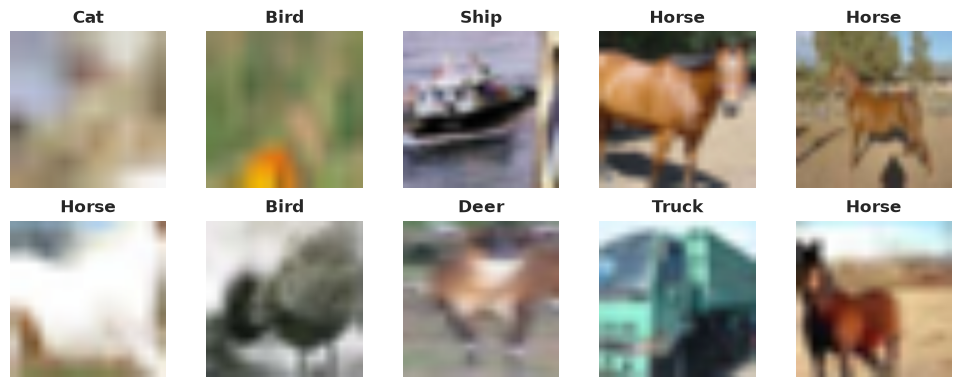

In [4]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE, num_workers=8)
data_iter = iter(dataloaders["train"])
xb, yb = next(data_iter)

N=10
visualize(xb[:N], yb[:N], dataloaders["train"])
plt.savefig(os.path.join(BASE_PLOTS, "cifar10_samples.pdf"), dpi=300)
plt.show()

In [5]:
def load_model(pretrained=True):
    weights = torchvision.models.ResNet152_Weights.IMAGENET1K_V1 if pretrained else None
    return torchvision.models.resnet152(weights=weights)

def add_clf_head(resnet):
    n_features = resnet.fc.in_features
    resnet.fc = nn.Linear(n_features, 10, bias=True)
    return resnet

In [6]:
model_baseline = add_clf_head(freeze_model(load_model())).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_baseline.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [7]:
tracker_baseline = GradientTracker(model_baseline)  # for comparison in Part 2

In [8]:
train_model("cnn-task_baseline", model_baseline, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 13m 48s
Best val Acc: 0.778700


In [9]:
tracker_baseline.unregister()

In [25]:
baseline_weight_grad_df = pd.DataFrame(tracker_baseline.gradients["fc.weight"])
baseline_weight_grad_df.to_json(os.path.join(BASE, "baseline_weight_gradients.json"), orient="records", lines=True)

  0%|          | 0/3 [00:00<?, ?it/s]

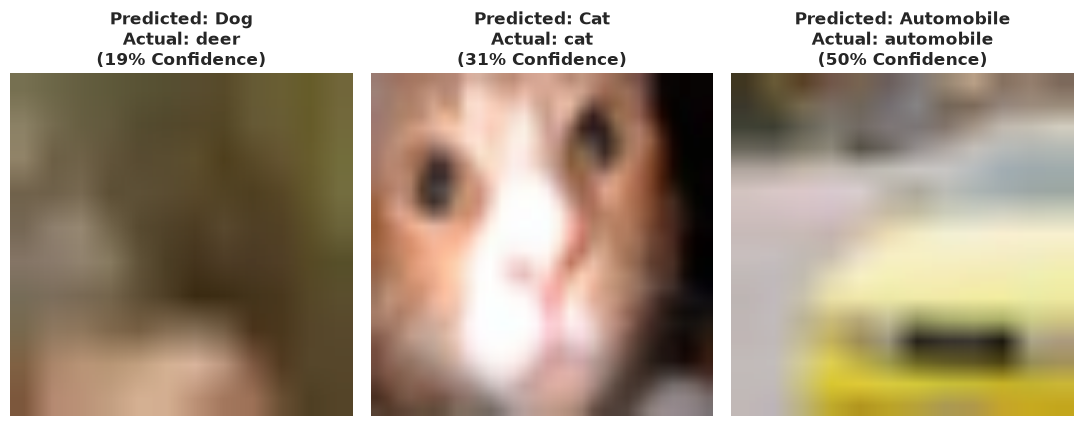

In [ ]:
def run_inference(model, image):
    image = image[None].to(DEVICE)
    outputs = model(image)
    confidence, predicted_label = torch.max(F.softmax(outputs, dim=-1), 1)
    return image[0], predicted_label, confidence

class_names = dataloaders["train"].dataset.classes
visualize_model(model_baseline, process_fn, [(xb[i], class_names[yb[i]]) for i in range(3)], class_names, run_inference)
plt.savefig(os.path.join(BASE_PLOTS, "cifar10_inference.pdf"), dpi=300)
plt.show()

In [21]:
del model_baseline
del criterion
del optimizer
del exp_sched

free_mem()

# 2. Residual Connections in Practice

In [6]:
def remove_skip_connections(model):
    def _overriden_forward(self, x):
        out = x
        
        out = self.conv1(out)
        out = self.bn1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = self.conv3(out)
        out = self.bn3(out)

        out = self.relu(out)
        
        return out
    
    for module in model.modules():
        if isinstance(module, torchvision.models.resnet.Bottleneck):
            module.forward = _overriden_forward.__get__(module, torchvision.models.resnet.Bottleneck)
    
    return model

In [7]:
model_no_skip = remove_skip_connections(add_clf_head(freeze_model(load_model()))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_no_skip.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [8]:
model_no_skip.layer1

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t

In [9]:
tracker_no_skip = GradientTracker(model_no_skip)  # for comparison with baseline

In [10]:
train_model("cnn-task_no-skip", model_no_skip, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

...

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Training complete in 10m 47s
Best val Acc: 0.110800


In [11]:
tracker_no_skip.unregister()

In [12]:
no_skip_weight_grad_df = pd.DataFrame(tracker_no_skip.gradients["fc.weight"])
no_skip_weight_grad_df.to_json(os.path.join(BASE, "no_skip_weight_gradients.json"), orient="records", lines=True)

In [13]:
baseline_weight_grad_df = pd.read_json(os.path.join(BASE, "baseline_weight_gradients.json"), orient="records", lines=True)
no_skip_weight_grad_df = pd.read_json(os.path.join(BASE, "no_skip_weight_gradients.json"), orient="records", lines=True)

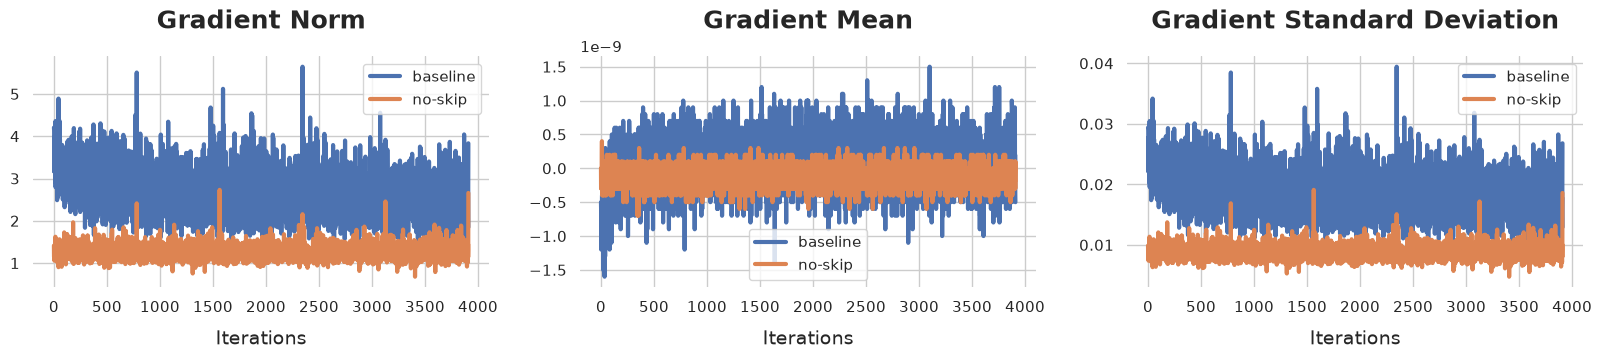

In [20]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,3))
sns.set_theme(style="whitegrid")

for (perf_df, label) in [
    (baseline_weight_grad_df, "baseline"),
    (no_skip_weight_grad_df, "no-skip"),
]:
    lineplot_kwargs = dict(markersize=0, linewidth=3, label=label)
    configs = [
        {
            "column": "norm",
            "title": "Gradient Norm",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "mean",
            "title": "Gradient Mean",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
        {
            "column": "std",
            "title": "Gradient Standard Deviation",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax3},
        },
    ]
    
    plot_line(perf_df, configs)

plt.savefig(os.path.join(BASE_PLOTS, "cifar10_gradients.pdf"), dpi=300)
plt.show()

In [15]:
del model_no_skip
del criterion
del optimizer
del exp_sched

free_mem()